In [3]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]
BURN_IN = 1000.0

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
GMAX = 12600.0
KGAMMA = 7 * 22000

AVOGADRO = 6.022e23
MW_NT = 330.0
MW_AA = 110.0

# ============================================================
# HELPERS
# ============================================================

def pearson_corr(x, y):
    if len(x) < 3:
        return np.nan
    return np.corrcoef(x, y)[0,1]

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_total = (r + rmm + rmt + rmq + rmr +
                  zmm + zmt + zmq + zmr)

    ribo_mass = NR * ribo_total
    non_ribo  = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo

    return ribo_total, ribo_mass, total_mass

def compute_active(df):
    return (
        df["rmm(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmq(t)"].to_numpy() +
        df["rmr(t)"].to_numpy()
    )

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)
    active = compute_active(df)
    lam = (active * gamma / total_mass) * 60.0
    return lam

def compute_rRNA_mass(df):
    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_nt = r_tot * RIBO_RNA_NT
    return (rRNA_nt / AVOGADRO) * MW_NT

def compute_protein_mass(df):
    r   = df["r(t)"]
    rmm = df["rmm(t)"]
    rmt = df["rmt(t)"]
    rmq = df["rmq(t)"]
    rmr = df["rmr(t)"]
    zmm = df["zmm(t)"]
    zmt = df["zmt(t)"]
    zmq = df["zmq(t)"]
    zmr = df["zmr(t)"]
    q   = df["q(t)"]
    et  = df["et(t)"]
    em  = df["em(t)"]

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr +
                      zmm + zmt + zmq + zmr)

    non_ribo  = NX * (q + et + em)
    total_aa  = (ribo_mass + non_ribo).to_numpy()

    return (total_aa / AVOGADRO) * MW_AA


# ============================================================
# BUILD SUMMARY
# ============================================================

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        # --- Model-unit masses ---
        ribo_total, ribo_mass_model, total_mass_model = compute_mass_components(df)

        active = compute_active(df)
        lam = compute_growth(df, total_mass_model)

        # --- Gram masses ---
        rRNA_mass = compute_rRNA_mass(df)
        protein_mass = compute_protein_mass(df)

        records.append({
            "ns": ns,
            "abx": abx,

            # Growth
            "growth": np.mean(lam),

            # Structural truth
            "ribo_total": np.mean(ribo_total),
            "rmf": np.mean(ribo_mass_model / total_mass_model),

            # Functional truth
            "active": np.mean(active),
            "active_fraction": np.mean(active / ribo_total),

            # Proxies (grams)
            "rRNA_mass": np.mean(rRNA_mass),
            "rRNA_ratio": np.mean(rRNA_mass / protein_mass)
        })

df_model = pd.DataFrame(records)

# ============================================================
# CORRELATION TABLE
# ============================================================

corr_results = []

for abx in ABX_VALUES:

    subset = df_model[df_model["abx"] == abx]

    corr_results.append({
        "abx": abx,
        "corr_rRNA_ribo_total": pearson_corr(subset["rRNA_mass"], subset["ribo_total"]),
        "corr_ratio_rmf": pearson_corr(subset["rRNA_ratio"], subset["rmf"]),
        "corr_rRNA_active": pearson_corr(subset["rRNA_mass"], subset["active"]),
        "corr_ratio_active_fraction": pearson_corr(subset["rRNA_ratio"], subset["active_fraction"]),
        "corr_growth_active": pearson_corr(subset["growth"], subset["active"]),
        "corr_growth_ratio": pearson_corr(subset["growth"], subset["rRNA_ratio"]),
        "corr_growth_rRNA": pearson_corr(subset["growth"], subset["rRNA_mass"])
    })

df_corr = pd.DataFrame(corr_results)

print("\n=== MODEL PROXY VALIDATION TABLE ===\n")
print(df_corr)


=== MODEL PROXY VALIDATION TABLE ===

   abx  corr_rRNA_ribo_total  corr_ratio_rmf  corr_rRNA_active  \
0    0                   1.0             1.0          0.999970   
1    2                   1.0             1.0          0.998081   
2    4                   1.0             1.0          0.997690   
3    8                   1.0             1.0          0.998179   
4   12                   1.0             1.0          0.955195   

   corr_ratio_active_fraction  corr_growth_active  corr_growth_ratio  \
0                   -0.966779            0.987844           0.998728   
1                    0.995719            0.998562           0.995457   
2                    0.996249            0.999133           0.995154   
3                    0.997852            0.999716           0.996746   
4                   -0.863071            0.999684          -0.858676   

   corr_growth_rRNA  
0          0.988982  
1          0.999962  
2          0.999646  
3          0.999331  
4          0.962119  

In [4]:
import numpy as np
import pandas as pd

# ============================================================
# LOAD RAMAN DATA
# ============================================================

rna_df = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

ABX_VALUES = sorted(growth_df["Dose"].unique())
nutrients = growth_df["Condition"].unique()

def pearson_corr(x, y):
    if len(x) < 3:
        return np.nan
    return np.corrcoef(x, y)[0,1]

# ============================================================
# BUILD SUMMARY (ACROSS NUTRIENTS)
# ============================================================

records = []

for nutrient in nutrients:
    for abx in ABX_VALUES:

        col = f"Cm{abx}_{nutrient}"
        if col not in rna_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA = RNA[:N]
        PROT = PROT[:N]

        # Remove negative values if needed
        mask = (RNA > 0) & (PROT > 0)
        RNA = RNA[mask]
        PROT = PROT[mask]

        mu_row = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == abx)
        ]

        if len(mu_row) == 0:
            continue

        lam = mu_row["Value"].values[0]  # already 1/hour

        records.append({
            "nutrient": nutrient,
            "abx": abx,
            "lambda": lam,
            "RNA_mean": np.mean(RNA),
            "ratio_mean": np.mean(RNA / PROT)
        })

df_raman = pd.DataFrame(records)

# ============================================================
# CORRELATIONS ACROSS NUTRIENTS (WITHIN ANTIBIOTIC)
# ============================================================

corr_results = []

for abx in ABX_VALUES:

    subset = df_raman[df_raman["abx"] == abx]

    corr_results.append({
        "abx": abx,
        "corr_growth_RNA": pearson_corr(
            subset["lambda"],
            subset["RNA_mean"]
        ),
        "corr_growth_ratio": pearson_corr(
            subset["lambda"],
            subset["ratio_mean"]
        )
    })

df_corr_raman = pd.DataFrame(corr_results)

print("\n=== RAMAN PROXY VALIDATION TABLE ===\n")
print(df_corr_raman)


=== RAMAN PROXY VALIDATION TABLE ===

   abx  corr_growth_RNA  corr_growth_ratio
0    0         0.971223           0.989135
1    2         0.978666           0.555693
2    4         0.986076          -0.855251
3    8         0.800515          -0.839572
4   12         0.923964          -0.882637


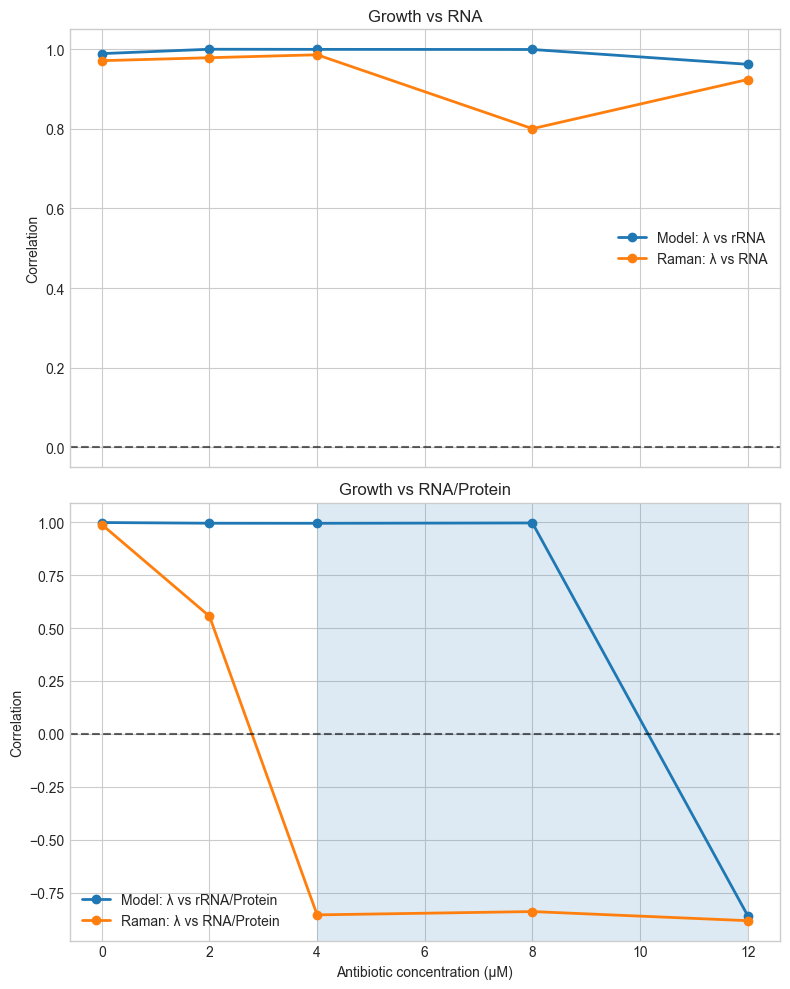

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

# Extract relevant model correlations
model_corr = df_corr.copy()
raman_corr = df_corr_raman.copy()

fig, axes = plt.subplots(2, 1, figsize=(8,10), sharex=True)

# ===============================
# Growth vs RNA
# ===============================
axes[0].plot(
    model_corr["abx"],
    model_corr["corr_growth_rRNA"],
    marker='o',
    linewidth=2,
    label="Model: λ vs rRNA"
)

axes[0].plot(
    raman_corr["abx"],
    raman_corr["corr_growth_RNA"],
    marker='o',
    linewidth=2,
    label="Raman: λ vs RNA"
)
axes[0].axhline(0, linestyle="--", color="black", alpha=0.6)
axes[0].set_ylabel("Correlation")
axes[0].set_title("Growth vs RNA")
axes[0].legend()

# ===============================
# Growth vs RNA/Protein
# ===============================
axes[1].plot(
    model_corr["abx"],
    model_corr["corr_growth_ratio"],
    marker='o',
    linewidth=2,
    label="Model: λ vs rRNA/Protein"
)

axes[1].plot(
    raman_corr["abx"],
    raman_corr["corr_growth_ratio"],
    marker='o',
    linewidth=2,
    label="Raman: λ vs RNA/Protein"
)
axes[1].axhline(0, linestyle="--", color="black", alpha=0.6)
axes[1].axvspan(4, max(df_corr["abx"]), alpha=0.15)
axes[1].set_xlabel("Antibiotic concentration (µM)")
axes[1].set_ylabel("Correlation")
axes[1].set_title("Growth vs RNA/Protein")
axes[1].legend()

plt.tight_layout()
plt.show()

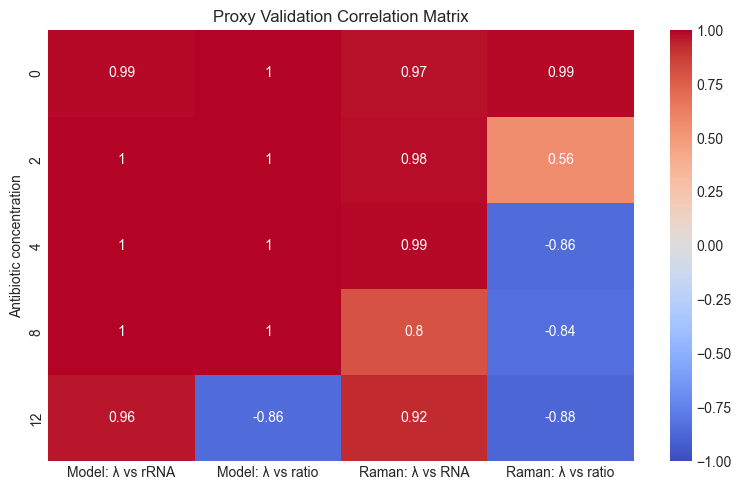

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine key correlations into one dataframe
heatmap_df = pd.DataFrame({
    "abx": df_corr["abx"],
    "Model: λ vs rRNA": df_corr["corr_growth_rRNA"],
    "Model: λ vs ratio": df_corr["corr_growth_ratio"],
    "Raman: λ vs RNA": df_corr_raman["corr_growth_RNA"],
    "Raman: λ vs ratio": df_corr_raman["corr_growth_ratio"]
})

heatmap_df = heatmap_df.set_index("abx")

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Proxy Validation Correlation Matrix")
plt.ylabel("Antibiotic concentration")
plt.xlabel("")
plt.tight_layout()
plt.show()